## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import string
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

## Loading the data

In [2]:
data_path = '../data/DANE.xlsx'

In [3]:
real_or_simulated = 'all' #simulated / real / all
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?

if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'

In [4]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

### Joining corresponding samples from inds and inks into one table

In [5]:
inks_df = inks_df.reset_index(drop=False)

In [6]:
inds_df = inds_df.reset_index(drop=False)

In [7]:
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inds', lsuffix='_inks')

### Removing some data

1. Let's remove rows with missing values.

In [8]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.030303030303030304

In [9]:
inDKs_df.dropna(inplace=True)

In [10]:
inDKs_df.shape

(3840, 64)

2. Let's keep only columns that we need.

In [11]:
inks_colnames = [col for col in inDKs_df.columns if (col.endswith('_inks') and 
                                                     col != 'nazwa próbki_inks'and
                                                    col != 'seria_inks' and
                                                    col != 'Fe_inks')]
inds_colnames = [col for col in inDKs_df.columns if (col.endswith('_inds') and 
                                                     col != 'nazwa próbki_inds'and
                                                    col != 'seria_inds' and
                                                    col != 'Fe_inds')]
#no iron because it's a reference element

### Creating features and labels matrices

In [12]:
X = np.array(inDKs_df[inds_colnames].values)
y = np.array(inDKs_df[inks_colnames].values)

### Train test split, datasets, dataloaders

In [13]:
if keep_sample_together:
    indices = list(range(int(X.shape[0]/15)))
    ind_train, ind_test = train_test_split(indices, test_size=0.3, random_state=1)
    
    ind_train_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_train]
    ind_train_all = [x for l in ind_train_all for x in l]
    ind_test_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_test]
    ind_test_all = [x for l in ind_test_all for x in l]

else:
    indices = list(range(int(X.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.3, random_state=1)

In [14]:
# partition = {'train': ind_train,
#             'validation': ind_val,
#             'test': ind_test}

partition = {'train': ind_train_all,
            'test': ind_test_all}

In [15]:
X_train = X[partition['train']]
y_train = y[partition['train']]

X_test = X[partition['test']]
y_test = y[partition['test']]

## PCA visualisation of X_train and X_test

In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
#X_train_pca = pca.fit_transform(X_train)

In [17]:
X_pca.shape
#for simulated: 1425 samples projected to 2D space
#for real: 2415 samples projected to 2D space

(3840, 2)

In [18]:
pca.components_.shape
#first column tells us about how much first feature contributes to PC1, PC2
#second column tells us about how much second feature contributes to PC1, PC2

(2, 29)

In [19]:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test) #transform instead of fit_transform!
#because we want to use this PCA that has already been calculated for X_train
#not the new one and new PC1, PC2, because then we cannot compare nor visualize

Text(0.5, 1.0, 'PCA projection')

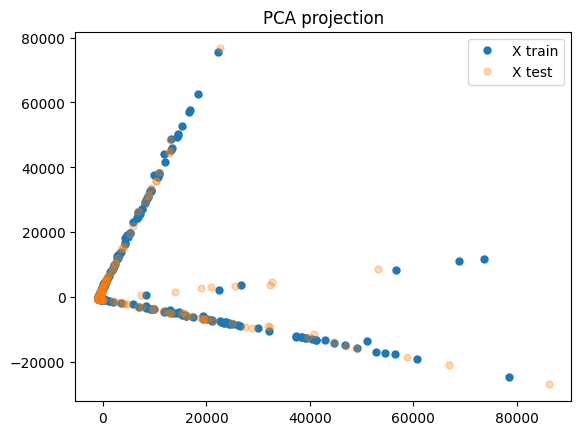

In [20]:
plt.plot(X_train_pca[:,0], X_train_pca[:,1], '.', markersize=10, label='X train')
plt.plot(X_test_pca[:,0], X_test_pca[:,1], '.', markersize=10, alpha=0.3, label='X test')
plt.legend()
plt.title('PCA projection')

## PCA visualisation of y_train and y_test

In [21]:
pca = PCA(n_components=2)
y_pca = pca.fit_transform(y)

In [22]:
y_pca.shape 
#for simulated: 1425 samples projected to 2D space
#for real: 2415 samples projected to 2D space

(3840, 2)

In [23]:
pca.components_.shape
#first column tells us about how much first feature contributes to PC1, PC2
#second column tells us about how much second feature contributes to PC1, PC2

(2, 29)

In [24]:
y_train_pca = pca.transform(y_train)
y_test_pca = pca.transform(y_test) #transform instead of fit_transform!
#because we want to use this PCA that has already been calculated for X_train
#not the new one and new PC1, PC2, because then we cannot compare nor visualize

Text(0.5, 1.0, 'PCA projection')

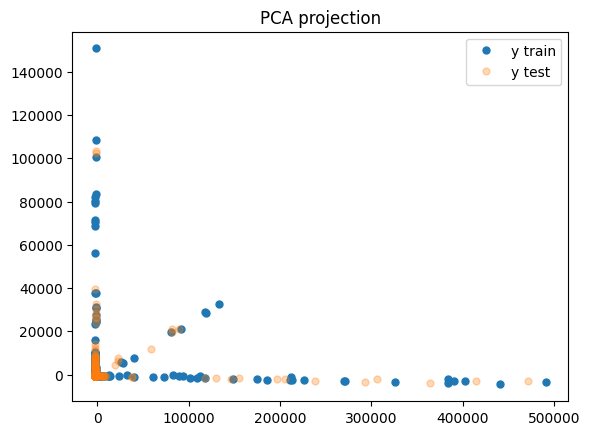

In [25]:
plt.plot(y_train_pca[:,0], y_train_pca[:,1], '.', markersize=10, label='y train')
plt.plot(y_test_pca[:,0], y_test_pca[:,1], '.', markersize=10, alpha=0.3, label='y test')
plt.legend()
plt.title('PCA projection')

### Identifying outliers

In [26]:
# #simulated X:
# np.logical_and(X_pca[:,0]>69000, X_pca[:,0]<70000).argmax()
# #simulated y
# PC1_cond = np.logical_and(y_pca[:,0]>128000, y_pca[:,0]<129000)
# PC2_cond = np.logical_and(y_pca[:,1]>32000, y_pca[:,1]<33000)
# np.logical_and(PC1_cond, PC2_cond).argmax()
#real X
#(X_pca[:,0]>1000).argmax()
#(y_pca[:,1]>500).argmax()

In [27]:
#outliers: 
#simulated X: 1035-1049
#simulated y: 1020 - 1034
#real X: 2370 - 2384
#real y: 2370 - 2384

In [28]:
outliers_indices = {
    'simulated': list(range(1035, 1050)) + list(range(1020, 1035)),
    'real': list(range(2370, 2385))
                    }

## PCA without outliers

In [29]:
X = np.array(inDKs_df[inds_colnames].values)
y = np.array(inDKs_df[inks_colnames].values)

if real_or_simulated == 'real':
    indices_to_remove = outliers_indices['real']
    indices_to_remove = list(set(indices_to_remove))
    X = np.delete(X, indices_to_remove, 0)
    y = np.delete(y, indices_to_remove, 0)
    
elif real_or_simulated == 'simulated':
    indices_to_remove = outliers_indices['simulated']
    indices_to_remove = list(set(indices_to_remove))
    X = np.delete(X, indices_to_remove, 0)
    y = np.delete(y, indices_to_remove, 0)
    
elif real_or_simulated == 'all':
    indices_to_remove = outliers_indices['simulated'] + \
                        [ind + 1425 for ind in outliers_indices['real']]
    indices_to_remove = list(set(indices_to_remove))
    X = np.delete(X, indices_to_remove, 0)
    y = np.delete(y, indices_to_remove, 0)

### Train test split, datasets, dataloaders

In [30]:
if keep_sample_together:
    indices = list(range(int(X.shape[0]/15)))
    ind_train, ind_test = train_test_split(indices, test_size=0.3, random_state=1)
    
    ind_train_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_train]
    ind_train_all = [x for l in ind_train_all for x in l]
    ind_test_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_test]
    ind_test_all = [x for l in ind_test_all for x in l]

else:
    indices = list(range(int(X.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.3, random_state=1)

In [31]:
# partition = {'train': ind_train,
#             'validation': ind_val,
#             'test': ind_test}

partition = {'train': ind_train_all,
            'test': ind_test_all}

In [32]:
X_train = X[partition['train']]
y_train = y[partition['train']]

X_test = X[partition['test']]
y_test = y[partition['test']]

## PCA visualisation of X_train and X_test

In [33]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
#X_train_pca = pca.fit_transform(X_train)

In [34]:
X_pca.shape
#for simulated: 1425 samples projected to 2D space
#for real: 2415 samples projected to 2D space

(3795, 2)

In [35]:
pca.components_.shape
#first column tells us about how much first feature contributes to PC1, PC2
#second column tells us about how much second feature contributes to PC1, PC2

(2, 29)

In [36]:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test) #transform instead of fit_transform!
#because we want to use this PCA that has already been calculated for X_train
#not the new one and new PC1, PC2, because then we cannot compare nor visualize

Text(0.5, 1.0, 'PCA projection')

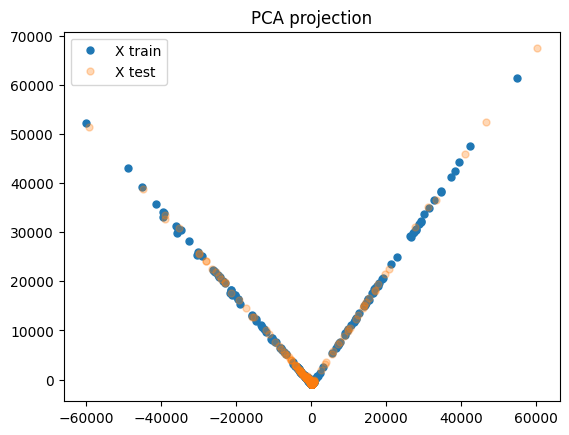

In [37]:
plt.plot(X_train_pca[:,0], X_train_pca[:,1], '.', markersize=10, label='X train')
plt.plot(X_test_pca[:,0], X_test_pca[:,1], '.', markersize=10, alpha=0.3, label='X test')
plt.legend()
plt.title('PCA projection')

## PCA visualisation of y_train and y_test

In [38]:
pca = PCA(n_components=2)
y_pca = pca.fit_transform(y)

In [39]:
y_pca.shape 
#for simulated: 1425 samples projected to 2D space
#for real: 2415 samples projected to 2D space

(3795, 2)

In [40]:
pca.components_.shape
#first column tells us about how much first feature contributes to PC1, PC2
#second column tells us about how much second feature contributes to PC1, PC2

(2, 29)

In [41]:
y_train_pca = pca.transform(y_train)
y_test_pca = pca.transform(y_test) #transform instead of fit_transform!
#because we want to use this PCA that has already been calculated for X_train
#not the new one and new PC1, PC2, because then we cannot compare nor visualize

Text(0.5, 1.0, 'PCA projection')

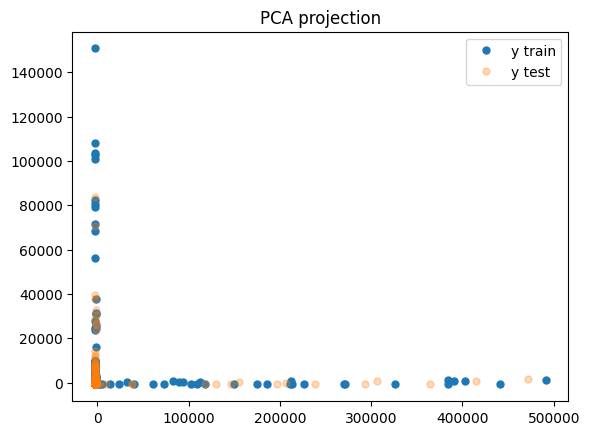

In [42]:
plt.plot(y_train_pca[:,0], y_train_pca[:,1], '.', markersize=10, label='y train')
plt.plot(y_test_pca[:,0], y_test_pca[:,1], '.', markersize=10, alpha=0.3, label='y test')
plt.legend()
plt.title('PCA projection')